# Dataset description

In [658]:
# Choose dataset to analyze
DATASET_NAME = "../data/1_eurostat_new_passenger_cars_by_type_of_motor_energy_and_engine_size.csv"

In [659]:
import pandas as pd

df = pd.read_csv(DATASET_NAME)

In [660]:
df.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,unit,Unit of measure,mot_nrg,Motor energy,engine,...,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:ROAD_EQR_CARMOT(1.0),New passenger cars by type of motor energy and...,A,Annual,NR,Number,DIE,Diesel,CC1400-1999,...,AT,Austria,1999,NaN,146817.0,NaN,d,definition differs (see metadata),NaN,NaN
1,dataflow,ESTAT:ROAD_EQR_CARMOT(1.0),New passenger cars by type of motor energy and...,A,Annual,NR,Number,DIE,Diesel,CC1400-1999,...,AT,Austria,2000,NaN,155684.0,NaN,d,definition differs (see metadata),NaN,NaN
2,dataflow,ESTAT:ROAD_EQR_CARMOT(1.0),New passenger cars by type of motor energy and...,A,Annual,NR,Number,DIE,Diesel,CC1400-1999,...,AT,Austria,2001,NaN,158020.0,NaN,d,definition differs (see metadata),NaN,NaN
3,dataflow,ESTAT:ROAD_EQR_CARMOT(1.0),New passenger cars by type of motor energy and...,A,Annual,NR,Number,DIE,Diesel,CC1400-1999,...,AT,Austria,2002,NaN,158103.0,NaN,d,definition differs (see metadata),NaN,NaN
4,dataflow,ESTAT:ROAD_EQR_CARMOT(1.0),New passenger cars by type of motor energy and...,A,Annual,NR,Number,DIE,Diesel,CC1400-1999,...,AT,Austria,2003,NaN,175893.0,NaN,NaN,NaN,NaN,NaN


In [661]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6422 entries, 0 to 6421
Data columns (total 21 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   STRUCTURE                               6422 non-null   object 
 1   STRUCTURE_ID                            6422 non-null   object 
 2   STRUCTURE_NAME                          6422 non-null   object 
 3   freq                                    6422 non-null   object 
 4   Time frequency                          6422 non-null   object 
 5   unit                                    6422 non-null   object 
 6   Unit of measure                         6422 non-null   object 
 7   mot_nrg                                 6422 non-null   object 
 8   Motor energy                            6422 non-null   object 
 9   engine                                  6422 non-null   object 
 10  Engine capacity of vehicle              6422 non-null   obje

In [662]:
for col in df.columns:
    print(f"Column {col}: {df[col].unique()}")

Column STRUCTURE: ['dataflow']
Column STRUCTURE_ID: ['ESTAT:ROAD_EQR_CARMOT(1.0)']
Column STRUCTURE_NAME: ['New passenger cars by type of motor energy and engine size']
Column freq: ['A']
Column Time frequency: ['Annual']
Column unit: ['NR']
Column Unit of measure: ['Number']
Column mot_nrg: ['DIE' 'PET' 'TOTAL']
Column Motor energy: ['Diesel' 'Petrol' 'Total']
Column engine: ['CC1400-1999' 'CC_GE2000' 'CC_LT1400' 'TOTAL']
Column Engine capacity of vehicle: ['From 1 400 to 1 999 cm³' '2 000 cm³ or over' 'Less than 1 400 cm³'
 'Total']
Column geo: ['AT' 'BA' 'BE' 'CH' 'CY' 'CZ' 'DE' 'EE' 'EL' 'ES' 'FI' 'FR' 'GE' 'HR'
 'HU' 'IE' 'IS' 'IT' 'LI' 'LT' 'LU' 'LV' 'MD' 'ME' 'MT' 'NO' 'PL' 'PT'
 'RO' 'RS' 'SE' 'SI' 'TR' 'UA' 'UK' 'XK' 'AL' 'BG' 'DK' 'EU27_2020' 'NL'
 'SK' 'MK']
Column Geopolitical entity (reporting): ['Austria' 'Bosnia and Herzegovina' 'Belgium' 'Switzerland' 'Cyprus'
 'Czechia' 'Germany' 'Estonia' 'Greece' 'Spain' 'Finland' 'France'
 'Georgia' 'Croatia' 'Hungary' 'Ireland' 'Ic

In [663]:
df["TIME_PERIOD"].min(), df["TIME_PERIOD"].max()

(1970, 2024)

In [664]:
df["geo"].nunique(), df["Geopolitical entity (reporting)"].unique()

(43,
 array(['Austria', 'Bosnia and Herzegovina', 'Belgium', 'Switzerland',
        'Cyprus', 'Czechia', 'Germany', 'Estonia', 'Greece', 'Spain',
        'Finland', 'France', 'Georgia', 'Croatia', 'Hungary', 'Ireland',
        'Iceland', 'Italy', 'Liechtenstein', 'Lithuania', 'Luxembourg',
        'Latvia', 'Moldova', 'Montenegro', 'Malta', 'Norway', 'Poland',
        'Portugal', 'Romania', 'Serbia', 'Sweden', 'Slovenia', 'Türkiye',
        'Ukraine', 'United Kingdom', 'Kosovo*', 'Albania', 'Bulgaria',
        'Denmark', 'European Union - 27 countries (from 2020)',
        'Netherlands', 'Slovakia', 'North Macedonia'], dtype=object))

In [665]:
# Map unique geo to continent
import country_converter as coco

df_continent = pd.DataFrame({
    "geo": df["geo"].drop_duplicates()
})

# Remove 'EU27_2020' entry from the list of unique geo values
df_continent = df_continent[df_continent["geo"] != "EU27_2020"]

df_continent["continent"] = coco.convert(
    names=df_continent["geo"],
    to="continent",
    not_found="Unknown"
)

# Count the number of countries per continent
df_continent.groupby("continent").size().reset_index(name="count")

,continent,count
0,Asia,3
1,Europe,39


# Data inspection, cleaning and preprocessing
## Drop unnecessary columns

In [666]:
# Drop columns with a single unique value
df.drop(columns=[
    'STRUCTURE',
    'STRUCTURE_ID',
    'STRUCTURE_NAME',
    'freq',
    'Time frequency',
    'unit',
    'Unit of measure',
    'Time',
    'Observation value'
], inplace=True)

# Drop description columns
df.drop(columns=[
    'mot_nrg',
    'engine',
    'Observation status (Flag) V2 structure',
    'Confidentiality status (flag)'
], inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6422 entries, 0 to 6421
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Motor energy                     6422 non-null   object 
 1   Engine capacity of vehicle       6422 non-null   object 
 2   geo                              6422 non-null   object 
 3   Geopolitical entity (reporting)  6422 non-null   object 
 4   TIME_PERIOD                      6422 non-null   int64  
 5   OBS_VALUE                        6406 non-null   float64
 6   OBS_FLAG                         584 non-null    object 
 7   CONF_STATUS                      16 non-null     object 
dtypes: float64(1), int64(1), object(6)
memory usage: 401.5+ KB


In [667]:
df['OBS_VALUE'].min(), df['OBS_VALUE'].max()

(0.0, 13235768.0)

In [668]:
df['TIME_PERIOD'].sort_values().unique()

array([1970, 1975, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987,
       1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998,
       1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009,
       2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022, 2023, 2024], dtype=int64)

In [669]:
for col in df.columns:
    print(f"Column {col}: {df[col].unique()}")

Column Motor energy: ['Diesel' 'Petrol' 'Total']
Column Engine capacity of vehicle: ['From 1 400 to 1 999 cm³' '2 000 cm³ or over' 'Less than 1 400 cm³'
 'Total']
Column geo: ['AT' 'BA' 'BE' 'CH' 'CY' 'CZ' 'DE' 'EE' 'EL' 'ES' 'FI' 'FR' 'GE' 'HR'
 'HU' 'IE' 'IS' 'IT' 'LI' 'LT' 'LU' 'LV' 'MD' 'ME' 'MT' 'NO' 'PL' 'PT'
 'RO' 'RS' 'SE' 'SI' 'TR' 'UA' 'UK' 'XK' 'AL' 'BG' 'DK' 'EU27_2020' 'NL'
 'SK' 'MK']
Column Geopolitical entity (reporting): ['Austria' 'Bosnia and Herzegovina' 'Belgium' 'Switzerland' 'Cyprus'
 'Czechia' 'Germany' 'Estonia' 'Greece' 'Spain' 'Finland' 'France'
 'Georgia' 'Croatia' 'Hungary' 'Ireland' 'Iceland' 'Italy' 'Liechtenstein'
 'Lithuania' 'Luxembourg' 'Latvia' 'Moldova' 'Montenegro' 'Malta' 'Norway'
 'Poland' 'Portugal' 'Romania' 'Serbia' 'Sweden' 'Slovenia' 'Türkiye'
 'Ukraine' 'United Kingdom' 'Kosovo*' 'Albania' 'Bulgaria' 'Denmark'
 'European Union - 27 countries (from 2020)' 'Netherlands' 'Slovakia'
 'North Macedonia']
Column TIME_PERIOD: [1999 2000 2001 2002 20

### Zeros observations

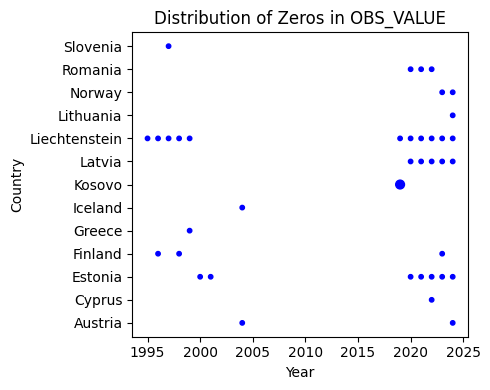

In [670]:
import matplotlib.pyplot as plt

zeros = df[df["OBS_VALUE"] == 0]
zero_counts = (
    zeros.groupby(["Geopolitical entity (reporting)", "TIME_PERIOD"])
    .size()
    .reset_index(name="zero_count")
)

# Rename Kosovo* to Kosovo
zero_counts["Geopolitical entity (reporting)"] = zero_counts["Geopolitical entity (reporting)"].replace("Kosovo*", "Kosovo")

plt.figure(figsize=(5, 4))

plt.scatter(
    zero_counts["TIME_PERIOD"],
    zero_counts["Geopolitical entity (reporting)"],
    s=zero_counts["zero_count"] * 10,  # bubble size * 10 to improve visibility
    color="blue"
)

plt.xlabel("Year")
plt.ylabel("Country")
plt.title("Distribution of Zeros in OBS_VALUE")

plt.tight_layout()
plt.savefig("img/zeros_distrib_in_OBS_VALUE.png", dpi=300)
plt.show()

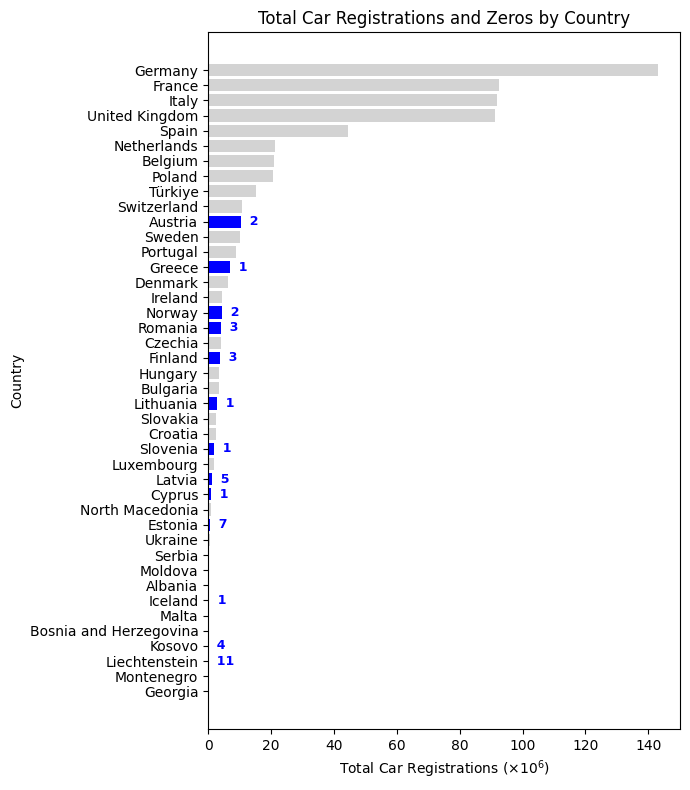

In [671]:
import matplotlib.pyplot as plt

total_registrations_per_country = (
    df[df["Motor energy"] == "Total"]
    .groupby("Geopolitical entity (reporting)")["OBS_VALUE"]
    .sum()
)
zero_observations_per_country = (
    df[df["OBS_VALUE"] == 0]
    .groupby("Geopolitical entity (reporting)")
    .size()
)

# [total_registrations, zero_observations]
plot_df = pd.DataFrame({
    "total_registrations": total_registrations_per_country,
    "zero_observations": zero_observations_per_country
}).fillna(0)
plot_df.rename(
    index={"Kosovo*": "Kosovo"},
    inplace=True
)
plot_df = plot_df.drop(
    index="European Union - 27 countries (from 2020)",
    errors="ignore"
)
plot_df = plot_df.sort_values("total_registrations")


fig, ax = plt.subplots(figsize=(7, 8))

# Blue bars for countries with zero observations, light gray for others
bar_colors = [
    "blue" if z > 0 else "lightgray"
    for z in plot_df["zero_observations"]
]

ax.barh(
    plot_df.index,
    plot_df["total_registrations"] / 1e6,
    color=bar_colors
)

# Labels for countries with zero observations
for country, registrations, zeros in zip(
    plot_df.index,
    plot_df["total_registrations"] / 1e6,
    plot_df["zero_observations"]
):
    if zeros > 0:
        ax.text(
            registrations,
            country,
            f"  {int(zeros)}",
            va="center",
            fontsize=9,
            fontweight="bold",
            color="blue"
        )

ax.set_xlabel("Total Car Registrations ($\\times10^6$)")
ax.set_ylabel("Country")

ax.set_title("Total Car Registrations and Zeros by Country")

plt.tight_layout()
plt.savefig("img/total_car_registrations_and_zeros_by_country.png", dpi=300)
plt.show()

### NaN observations for the "OBS_VALUE" column

In [672]:
# Check for NaN values in the OBS_VALUE column
nan_obs_value = df[df["OBS_VALUE"].isna()]

display(nan_obs_value) # All are <=2009

,Motor energy,Engine capacity of vehicle,geo,Geopolitical entity (reporting),TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
541,Diesel,From 1 400 to 1 999 cm³,UK,United Kingdom,2006,NaN,NaN,C
542,Diesel,From 1 400 to 1 999 cm³,UK,United Kingdom,2007,NaN,NaN,C
1098,Diesel,2 000 cm³ or over,UK,United Kingdom,2006,NaN,NaN,C
1099,Diesel,2 000 cm³ or over,UK,United Kingdom,2007,NaN,NaN,C
1639,Diesel,Less than 1 400 cm³,UK,United Kingdom,2006,NaN,NaN,C
1640,Diesel,Less than 1 400 cm³,UK,United Kingdom,2007,NaN,NaN,C
2526,Diesel,Total,UK,United Kingdom,2006,NaN,NaN,C
2527,Diesel,Total,UK,United Kingdom,2007,NaN,NaN,C
3086,Petrol,From 1 400 to 1 999 cm³,UK,United Kingdom,2007,NaN,NaN,C
3644,Petrol,2 000 cm³ or over,UK,United Kingdom,2007,NaN,NaN,C


### Flags

- (d) is definition differs (see metadata)
- (e) is estimated
- (b) is break in time series
- (i) is value imputed by Eurostat or other receiving agencies
- (u) is low reliability
- (p) is provisional

In [673]:
flag_counts = (
    df["OBS_FLAG"]
    .value_counts(dropna=False)
    .rename_axis("Flag")
    .reset_index(name="Count")
)

flag_counts["Percentage"] = (
    flag_counts["Count"] / len(df) * 100
)

display(flag_counts)

,Flag,Count,Percentage
0,NaN,5838,90.906260
1,d,407,6.337590
2,i,100,1.557147
3,e,32,0.498287
4,u,24,0.373715
5,b,17,0.264715
6,p,4,0.062286


In [674]:
df[df["OBS_FLAG"] == "b"].sort_values(
    ["geo", "TIME_PERIOD"]
)

,Motor energy,Engine capacity of vehicle,geo,Geopolitical entity (reporting),TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
4412,Petrol,Total,DK,Denmark,2020,138421.0,b,NaN
5486,Total,Total,EL,Greece,2013,58659.0,b,NaN
5671,Total,Total,HR,Croatia,2013,27802.0,b,NaN
344,Diesel,From 1 400 to 1 999 cm³,LT,Lithuania,2013,4427.0,b,NaN
902,Diesel,2 000 cm³ or over,LT,Lithuania,2013,2403.0,b,NaN
1444,Diesel,Less than 1 400 cm³,LT,Lithuania,2013,189.0,b,NaN
2891,Petrol,From 1 400 to 1 999 cm³,LT,Lithuania,2013,2867.0,b,NaN
3450,Petrol,2 000 cm³ or over,LT,Lithuania,2013,1444.0,b,NaN
4008,Petrol,Less than 1 400 cm³,LT,Lithuania,2013,925.0,b,NaN
2375,Diesel,Total,PL,Poland,2013,102495.0,b,NaN


In [675]:
df[df["OBS_FLAG"]=="b"].groupby("TIME_PERIOD").size() # As most of the "b" flags are <=2013 it is suggested to consider data from 2014 onwards for analysis

TIME_PERIOD
2009     6
2013    10
2020     1
dtype: int64

In [676]:
df[df["OBS_FLAG"]=="d"].groupby("TIME_PERIOD").size() # As most of the "d" flags are <=2012 it is suggested to consider data from 2013 onwards for analysis

TIME_PERIOD
1970     9
1975     9
1980    11
1985    11
1990     5
1991     5
1992     7
1993     7
1994     4
1995     2
1996    12
1997    11
1998    13
1999    11
2000    11
2001    12
2002    16
2003    21
2004    19
2005     5
2006    30
2007    24
2008    35
2009    36
2010    30
2011    31
2012    20
dtype: int64

### Confidential status flag

- (C) is confidential

In [677]:
conf = df[df["CONF_STATUS"] == "C"]

display(conf)

,Motor energy,Engine capacity of vehicle,geo,Geopolitical entity (reporting),TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
541,Diesel,From 1 400 to 1 999 cm³,UK,United Kingdom,2006,NaN,NaN,C
542,Diesel,From 1 400 to 1 999 cm³,UK,United Kingdom,2007,NaN,NaN,C
1098,Diesel,2 000 cm³ or over,UK,United Kingdom,2006,NaN,NaN,C
1099,Diesel,2 000 cm³ or over,UK,United Kingdom,2007,NaN,NaN,C
1639,Diesel,Less than 1 400 cm³,UK,United Kingdom,2006,NaN,NaN,C
1640,Diesel,Less than 1 400 cm³,UK,United Kingdom,2007,NaN,NaN,C
2526,Diesel,Total,UK,United Kingdom,2006,NaN,NaN,C
2527,Diesel,Total,UK,United Kingdom,2007,NaN,NaN,C
3086,Petrol,From 1 400 to 1 999 cm³,UK,United Kingdom,2007,NaN,NaN,C
3644,Petrol,2 000 cm³ or over,UK,United Kingdom,2007,NaN,NaN,C


### Drop flag columns

In [678]:
df.drop(columns=[
    'OBS_FLAG',
    'CONF_STATUS'
], inplace=True)

### Restrict from 2014 to 2024

In [679]:
df = df[df["TIME_PERIOD"] >= 2014]
df = df[df["TIME_PERIOD"] <= 2024]

df["TIME_PERIOD"].min(), df["TIME_PERIOD"].max()

(2014, 2024)

### Drop non EU27_2020 countries

In [680]:
eu27_2020 = ['BE', 'BG', 'CZ', 'DK', 'DE', 'EE', 'IE', 'EL', 'ES', 'FR', 'HR', 'IT', 'CY', 'LV', 'LT', 'LU', 'HU', 'MT', 'NL', 'AT', 'PL', 'PT', 'RO', 'SI', 'SK', 'FI', 'SE']
len(eu27_2020)

27

In [681]:
# Check wether the df contains all the EU27_2020 countries
df_countries = df["geo"].unique().tolist()
all_countries_in_df = all(country in df_countries for country in eu27_2020)

print(all_countries_in_df) # True, all EU27_2020 countries are present in the dataset

True


In [682]:
# Filter the dataset to include only EU27_2020 countries
df = df[df["geo"].isin(eu27_2020)]

print(df["geo"].nunique()) # 27, only EU27_2020 countries are present in the dataset

27


In [683]:
df.to_csv('../data/cleaned/1c_eurostat_new_passenger_cars_by_type_of_motor_energy_and_engine_size.csv', index=False)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2028 entries, 14 to 6332
Data columns (total 6 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Motor energy                     2028 non-null   object 
 1   Engine capacity of vehicle       2028 non-null   object 
 2   geo                              2028 non-null   object 
 3   Geopolitical entity (reporting)  2028 non-null   object 
 4   TIME_PERIOD                      2028 non-null   int64  
 5   OBS_VALUE                        2028 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 110.9+ KB
